# EDA & Cleaning — EPA GHGRP Emissions Data

Exploratory pass over the raw facility-level data before it goes through the
production `src/etl.py` pipeline. Goals:
- Sanity-check the raw export (columns, types, missingness)
- Look at the distribution of reported emissions and spot obvious outliers
- Confirm the cleaned/classified output from the pipeline looks right


In [1]:
import sys
sys.path.append('../src')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

pd.set_option('display.max_columns', 50)


## 1. Load raw data

In [2]:
raw = pd.read_csv('../data/raw/ghgrp_sample_2019_2023.csv')
print(raw.shape)
raw.head()


FileNotFoundError: [Errno 2] No such file or directory: '../data/raw/ghgrp_sample_2019_2023.csv'

In [ ]:
raw.info()


In [3]:
# Missingness check
raw.isna().sum().sort_values(ascending=False)


NameError: name 'raw' is not defined

## 2. Run the production ETL pipeline

In [5]:
from etl import run_pipeline

clean_df = run_pipeline(
    input_glob='../data/raw/*.csv',
    output_path='../data/processed/emissions_clean.csv'
)
clean_df.shape


[1/5] Loading raw data from '../data/raw/*.csv'...
  loaded ../data/raw/ghgrp_sample_2019_2023.csv: 1,104 rows, 14 cols
  combined: 1,104 rows from 1 file(s)
[2/5] Cleaning...
  clean(): dropped 3 rows with null facility_id; flagged 8 rows with non-positive/missing emissions (kept, not dropped)
[3/5] Validating...
  validate(): found 8 duplicate facility-year rows (flagged, not dropped)
  validate(): flagged 20 outlier rows (|z| > 3 within sector) — kept, not dropped
[4/5] Classifying by GHG Protocol scope...
[5/5] Exporting...
  wrote 1,101 rows -> ../data/processed/emissions_clean.csv


(1101, 22)

## 3. Distribution of reported emissions

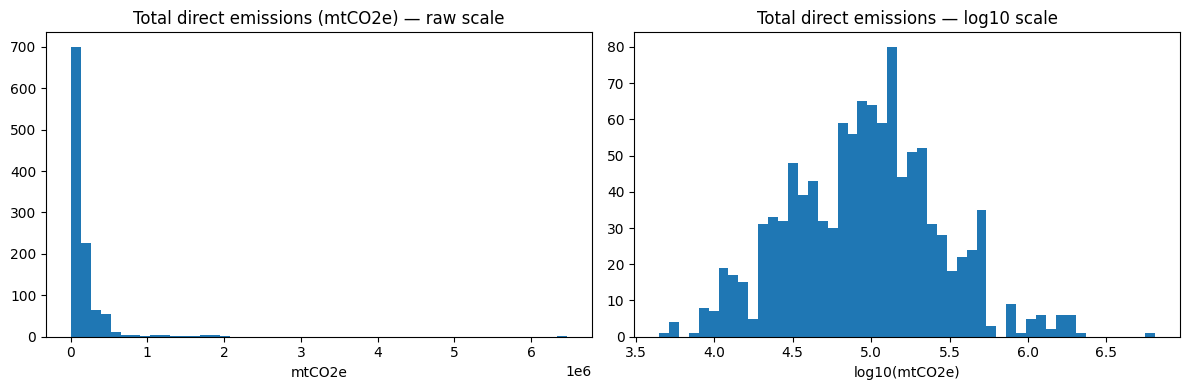

In [6]:
valid = clean_df[~clean_df['flag_nonpositive_emissions']]

fig, ax = plt.subplots(1, 2, figsize=(12, 4))
ax[0].hist(valid['total_direct_emissions_mtco2e'], bins=50)
ax[0].set_title('Total direct emissions (mtCO2e) — raw scale')
ax[0].set_xlabel('mtCO2e')

ax[1].hist(np.log10(valid['total_direct_emissions_mtco2e']), bins=50)
ax[1].set_title('Total direct emissions — log10 scale')
ax[1].set_xlabel('log10(mtCO2e)')

plt.tight_layout()
plt.show()


Emissions are right-skewed, as expected for facility-level industrial data — a small
number of large facilities dominate total reported emissions. This is why sector-level
z-scores (rather than a single dataset-wide threshold) are used for outlier flagging in
`etl.py`: a "normal" large facility in Power Plants would look like an outlier compared
to a small Chemicals facility, and vice versa.

## 4. Emissions trend over time, by sector

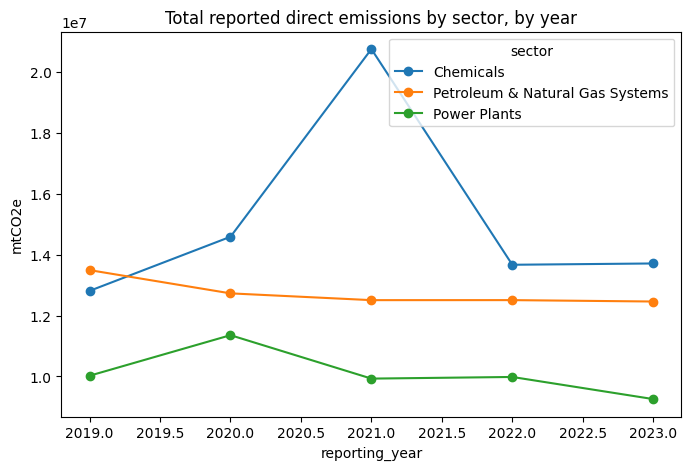

sector,Chemicals,Petroleum & Natural Gas Systems,Power Plants
reporting_year,,,
2019,12810684.7,13492652.7,10021573.2
2020,14589575.1,12728604.1,11354194.4
2021,20758844.2,12505809.7,9926534.9
2022,13668819.8,12506553.2,9980474.8
2023,13711526.2,12460716.9,9253459.3


In [7]:
trend = (
    valid.groupby(['reporting_year', 'sector'])['total_direct_emissions_mtco2e']
    .sum()
    .unstack('sector')
)
trend.plot(marker='o', figsize=(8, 5), title='Total reported direct emissions by sector, by year')
plt.ylabel('mtCO2e')
plt.show()
trend


## 5. Flagged rows review

In [8]:
flag_cols = ['flag_nonpositive_emissions', 'flag_duplicate_facility_year', 'flag_outlier']
clean_df[flag_cols].sum()


flag_nonpositive_emissions       8
flag_duplicate_facility_year     8
flag_outlier                    20
dtype: int64

In [9]:
clean_df[clean_df['flag_outlier']][
    ['facility_id', 'facility_name', 'sector', 'reporting_year',
     'total_direct_emissions_mtco2e', 'emissions_zscore']
].sort_values('emissions_zscore', ascending=False)


,facility_id,facility_name,sector,reporting_year,total_direct_emissions_mtco2e,emissions_zscore
599,GHGRP100016,Union Petroleum Plant 16,Chemicals,2021,6466892.0,14.252480
240,GHGRP100001,Bayview Chemicals Plant 1,Power Plants,2020,1356456.0,8.225759
453,GHGRP100131,Riverbend Petroleum Plant 131,Petroleum & Natural Gas Systems,2020,1919468.4,6.533321
703,GHGRP100131,Riverbend Petroleum Plant 131,Petroleum & Natural Gas Systems,2023,1912469.8,6.507118
214,GHGRP100131,Riverbend Petroleum Plant 131,Petroleum & Natural Gas Systems,2021,1719600.8,5.784996
75,GHGRP100131,Riverbend Petroleum Plant 131,Petroleum & Natural Gas Systems,2022,1698986.9,5.707816
550,GHGRP100131,Riverbend Petroleum Plant 131,Petroleum & Natural Gas Systems,2019,1647894.8,5.516522
389,GHGRP100070,Prairie Chemicals Plant 70,Chemicals,2020,2052887.5,4.225605
178,GHGRP100000,Cedar Point Power Plant 0,Petroleum & Natural Gas Systems,2022,1240681.3,3.991873
99,GHGRP100108,Cedar Point Petroleum Plant 108,Chemicals,2020,1930749.4,3.948156


These flagged rows are **kept** in `data/processed/emissions_clean.csv`, not dropped —
the `flag_outlier` column lets the Tableau dashboard (or any downstream consumer) filter
them in or out explicitly. See the README's Methodology section for why.